In [1]:
import numpy as np
import pytz

from Data_query.trino_config import *
from visualisation import *

In [10]:
stop_trino()

Trino service stopping triggered.


In [5]:
big_workers = 8
workers = 0
num_workers = max(workers, big_workers)
ensure_trino_running(worker_desired_count=workers, big_worker_desired_count=big_workers)
sleep(40)

Trino service is not running. Starting the service...
Trino service triggered.
Service trino-service is now stable.


In [19]:
iceberg_sql(f"""select * from ts limit 2""")

,circuit_id,t_stamp,power,energy,energy_reactive,energy_import,energy_export,energy_reactive_import,energy_reactive_export,power_factor,voltage,current,year,month,is_pv,postcode
0,359742,2024-06-26 22:45:00,201.4667,16.7889,-2.9261,16.7889,0.000,0.00,2.9261,0.970519,243.6,0.977,2024,6,True,4870
1,359742,2024-06-28 13:05:00,-0.4200,-0.0350,0.0300,0.0000,0.035,0.03,0.0000,0.576471,247.2,0.000,2024,6,True,4870


In [6]:
sleep(20)

In [7]:
# ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
# sleep(40)
# site_id = 2124568132 # big site
# site_id = 1954814618 # flexible export
def run_func(args):
    year, month, split_cons = args
    state = "QLD"
    df = iceberg_sql(f"""
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(power*circuit_polarity)/1000 as P_kw
                        from ts join (select site_id, circuit_id, circuit_polarity  from meta_up23c where state='{state}' and is_pv=True and {split_cons})
                            as m on ts.circuit_id = m.circuit_id
                        where year = {year} and  month = {month}  and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons}
                        group by site_id, t_stamp
                            ),
                        daily_site_maxP AS (
                            SELECT 
                                site_id,
                                date_trunc('day', t_stamp + interval '10' hour) AS day,
                                max(P_kw) AS max_P_kw
                            FROM data
                            group by site_id, date_trunc('day', t_stamp + interval '10' hour)
                        ),
                        base AS (
                                SELECT
                                    d.*,
                                    lag(P_kw) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw,
                                    lag(P_kw, 2) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw2,
                                    lag(P_kw, 3) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw3,
                                    lag(P_kw, 4) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw4
                                FROM data d
                            )
                            SELECT 
                                b.site_id
                            from base b 
                                join daily_site_maxP as p on 
                                    b.site_id = p.site_id and date_trunc('day', b.t_stamp + interval '10' hour) = p.day
                                join (select distinct site_id, ac_capacity_kw  from meta_up23c where state='{state}' and is_pv=True and {split_cons}) m
                                    on b.site_id = m.site_id
                            where 
                                P_kw >= .2*ac_capacity_kw
                                AND P_kw <= .75*max_P_kw
                                AND ac_capacity_kw >= 5
                                AND prev_P_kw IS NOT NULL
                                AND prev_P_kw2 IS NOT NULL
                                AND prev_P_kw3 IS NOT NULL
                                AND prev_P_kw4 IS NOT NULL
                            group by b.site_id,  date_trunc('day', t_stamp + interval '10' hour) 
                            having min(greatest(P_kw , prev_P_kw , prev_P_kw2, prev_P_kw3, prev_P_kw4) - least(P_kw , prev_P_kw , prev_P_kw2, prev_P_kw3, prev_P_kw4)) < .004
    """)
    flex_export_sites = df["site_id"].unique()
    print(
        f"Found {len(flex_export_sites)} flex export sites for year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}"
    )
    if len(flex_export_sites) == 0:
        # print('hi')
        return None
    df = iceberg_sql(f"""
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(power*circuit_polarity)/1000 as P_kw,
                            sum(energy_reactive*circuit_polarity )/1000*12 as Q_kvar, avg(voltage) as v_avg 
                        from ts join 
                            (select site_id, circuit_id, circuit_polarity  from meta_up23c where state='{state}' and is_pv=True and {split_cons} and site_id in ({",".join(map(str, flex_export_sites))}))
                            as m on ts.circuit_id = m.circuit_id
                        where year = {year} and  month = {month}  and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons}
                        group by site_id, t_stamp
                            ),
                    bom10min as (
                        select 
                            distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                        from bom_nci.solar as b
                            join (select distinct site_id, n_lat, n_long from meta_up23c where state='{state}' and {split_cons} and site_id in ({",".join(map(str, flex_export_sites))})) as m 
                            on b.latitude = m.n_lat and b.longitude = m.n_long
                        where year = {year} and  month = {month}  and {split_cons} 
                    ),
                    bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                    from bom10min) union all
                    (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                    GHI, cloud_type
                    FROM bom10min
                    ORDER BY time_5min)),
                    daily_cloud AS (
                        SELECT
                            latitude, longitude,
                            date_trunc('day', time + interval '10' hour)   AS day,
                            date_trunc('month', time + interval '10' hour) AS month,
                            sum(cloud_type) AS cloud_sum, 
                            max(GHI) AS max_GHI
                        FROM bom10min
                        GROUP BY
                            1, 2, 3, 4
                    ),
                    clear_sky AS (
                            SELECT day, latitude, longitude
                            FROM (SELECT day, latitude, longitude, cloud_sum, max_GHI, row_number() OVER (
                                                                    PARTITION BY month, latitude, longitude
                                                                    ORDER BY cloud_sum ASC
                                                                    ) AS rn
                                FROM daily_cloud 
                            )
                            WHERE rn < 4 and cloud_sum < 60 and max_GHI > 200
                        ),
                    base AS (
                            SELECT
                                d.*,
                                lag(t_stamp) OVER (
                                    PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                    ORDER BY t_stamp
                                ) AS prev_ts
                            FROM data d
                    ),
                    gaps AS (
                        SELECT *,
                            CASE
                                WHEN prev_ts IS NULL THEN 0
                                WHEN t_stamp - prev_ts > interval '30' minute THEN 1
                                ELSE 0
                            END AS gap_start
                        FROM base
                    ),
                    segments AS (
                        SELECT *,
                            sum(gap_start) OVER (
                                PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                ORDER BY t_stamp
                                ROWS UNBOUNDED PRECEDING
                            ) AS segment_id
                        FROM gaps
                    )
                    select  d.*, sqrt(pow(P_kw, 2) + pow(Q_kvar, 2)) as S_kva, P_kw / (sqrt(pow(P_kw, 2) + pow(Q_kvar, 2))) as pf, 
                        GHI, cloud_type, ac_capacity_kw, export_limit_kw,
                        approx_percentile(P_kw, 0.6) OVER (
                            PARTITION BY d.site_id, date_trunc('day', d.t_stamp + interval '10' hour), segment_id
                                ORDER BY t_stamp
                                ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                            ) AS P_est
                    from 
                        segments as d  join (select distinct site_id, n_long, n_lat, ac_capacity_kw, export_limit_kw  from meta_up23c where state='{state}' and is_pv=True and {split_cons} and site_id in ({",".join(map(str, flex_export_sites))})) m
                        on d.site_id = m.site_id
                        join bom5min as b on 
                        m.n_lat = b.latitude and m.n_long = b.longitude and d.t_stamp = b.time_5min
                        join clear_sky as c on m.n_lat = c.latitude and m.n_long = c.longitude and date_trunc('day', t_stamp + interval '10' hour) = c.day
                    order by 
                        t_stamp
                        
                
    """)
    print(
        f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}"
    )
    # sleep(60)
    # print(df.head(1))
    return df


tasks = [
    (year, month, split_cons)
    for year in (2024,)
    for month in range(1, 13)
    for split_cons in [
        "system.bucket(postcode, 16) <= 3",
        "(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)",
        "(system.bucket(postcode, 16) > 7 and system.bucket(postcode, 16) <= 11)",
        "system.bucket(postcode, 16) > 11",
    ]
]
#  for split_cons in [f'system.bucket(postcode, 16) = {i}' for i in range(0, 16)]]


try:
    df = trino_parallel(run_func, tasks, num_workers=num_workers)
    df["t_stamp"] = (
        pd.to_datetime(df["t_stamp"])
        .dt.tz_localize("utc")
        .dt.tz_convert(pytz.FixedOffset(10 * 60))
    )
    df["GHI"] = df["GHI"].fillna(-1)
    df["cloud_type"] = df["cloud_type"].fillna(-1)
except Exception as e:
    print(f"Error during data retrieval: {e}")
finally:
    stop_trino()
    pass
df[:2]

Found 4 flex export sites for year=2024, month=2, bucket <= 3
Found 6 flex export sites for year=2024, month=2, (bucket > 3 and bucket <= 7)
Found 6 flex export sites for year=2024, month=1, (bucket > 7 and bucket <= 11)
Found 9 flex export sites for year=2024, month=1, bucket <= 3
Found 4 flex export sites for year=2024, month=2, bucket > 11
Found 4 flex export sites for year=2024, month=1, bucket > 11
Found 7 flex export sites for year=2024, month=1, (bucket > 3 and bucket <= 7)
Found 2 flex export sites for year=2024, month=2, (bucket > 7 and bucket <= 11)
Completed year=2024, month=2, bucket <= 3
Completed year=2024, month=1, (bucket > 3 and bucket <= 7)
Completed year=2024, month=2, (bucket > 3 and bucket <= 7)
Completed year=2024, month=1, (bucket > 7 and bucket <= 11)
Completed year=2024, month=1, bucket > 11
Completed year=2024, month=2, (bucket > 7 and bucket <= 11)
Completed year=2024, month=2, bucket > 11
Completed year=2024, month=1, bucket <= 3
Found 4 flex export sites fo

,site_id,t_stamp,P_kw,Q_kvar,v_avg,prev_ts,gap_start,segment_id,S_kva,pf,GHI,cloud_type,ac_capacity_kw,export_limit_kw,P_est
0,2030882339,2024-02-02 05:20:00+10:00,-0.000920,0.023900,242.8,2024-02-01 19:15:00,0,0,0.023918,-0.038465,3.75,0,8.0,NaN,-0.00092
1,2030882339,2024-02-02 05:25:00+10:00,-0.000927,0.023887,242.8,2024-02-01 19:20:00,0,0,0.023905,-0.038766,3.75,0,8.0,NaN,0.08009


In [9]:
df["site_id"].nunique()

149

In [10]:
id_counter = -1

In [34]:
id_counter += 1
sample_site_id = df.groupby("site_id").size().reset_index()
sample_site_id = sample_site_id[sample_site_id[0] > 0]["site_id"].tolist()
df0 = df.query(f"site_id=={sample_site_id[id_counter]}").reset_index(drop=True)
t0 = df0["t_stamp"].min()
t1 = df0["t_stamp"].max()
if t0.time() == pd.Timestamp("00:00:00").time():
    start_time = t0.strftime("%Y-%m-%d %H:%M:%S%z")
else:
    start_time = (
        (t0 + pd.Timedelta(days=1))
        .replace(hour=0, minute=0, second=0)
        .strftime("%Y-%m-%d %H:%M:%S%z")
    )
if t1.time() == pd.Timestamp("00:00:00").time():
    end_time = t1.strftime("%Y-%m-%d %H:%M:%S%z")
else:
    end_time = t1.replace(hour=0, minute=0, second=0).strftime("%Y-%m-%d %H:%M:%S%z")
# start_time = df0['t_stamp'].min().strftime('%Y-%m-%d %H:%M:%S%z')	 # In sydney local time


num_ticks = 24 * 2 + 1
save_as = "Figures/Test.jpeg"
x_label = "time"
y_labels = [
    "GHI",
    "Cloud Type",
    "Active Power (kW)",
    "Active Power (kW)",
    "Reactive Power (kVAR)",
]
# y_labels = ['GHI', 'Cloud Type', 'Apparent Power (kVA)', 'Average Voltage (V)', 'Power Factor']
plt_config = {
    "GHI": [0, 0, "-", None, None],
    "cloud_type": [0, 1, "-", None, None],
    "P_kw": [1, 0, "-", None, None],
    "P_est": [1, 0, "-", None, None],
    "Q_kvar": [1, 1, "-", None, None],
}
# 'S_kva': [1, 0, '-', None, None], 'v_avg': [1, 1, '-', None, None], 'pf': [2, 0, '-', None, None]}

color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.1f"
a = my_plot4(
    start_time,
    end_time,
    df0,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="site_id",
    time_attr="t_stamp",
    color_nights=color_nights,
    cmap="plasma",
    figsize=[16 / 2.54, 1.3],
    same_scale=1,
    fontsize=5,
    fontname="DejaVu Sans",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=200,
    x_format="%H:%M",
    legend_loc=["upper left", "upper right", "center left", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.2, 0.2],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
    onlyntime=0,
    show=False,
)
a.do()
print(df0["ac_capacity_kw"].unique())
print(df0["export_limit_kw"].unique())
# df['t_stamp'].dt.date.nunique()

saved as:  /home/hossein/CICCADA/Figures/Test.jpeg
[10.]
[nan]


In [ ]:
def run_func(args):
    year, month, split_cons = args
    df = iceberg_sql(f"""
                    with data as 
                     (select site_id, t_stamp,
                     sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw 
                    from ts  join (select site_id, circuit_id, circuit_polarity from meta_up23c where state='QLD' and is_pv=True and {split_cons}) as m on 
                     ts.circuit_id = m.circuit_id
                    where year = {year} and month = {month} and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons} 
                    group by site_id, t_stamp),
                    daily_site_maxP AS (
                            SELECT site_id,
                                date_trunc('day', t_stamp + interval '10' hour) AS day, 
                                max(P_kw) AS max_P_kw
                            FROM data
                            group by site_id, date_trunc('day', t_stamp + interval '10' hour)
                        ),
                    flex_export_sites AS (
                        SELECT 
                            b.site_id
                            from data b join daily_site_maxP as p on b.site_id = p.site_id and date_trunc('day', b.t_stamp + interval '10' hour) = p.day
                        where 
                            P_kw >= .2*10
                    )
                    SELECT d.*
                    FROM data d join flex_export_sites f on d.site_id = f.site_id
                    limit 1000

                
    """)
    sleep(2)
    return df


tasks = [
    (year, month, split_cons)
    for year in (2024,)
    for month in range(11, 12)
    for split_cons in [f"system.bucket(postcode, 16) = {i}" for i in range(1)]
]
try:
    df = trino_parallel(run_func, tasks, num_workers=num_workers)
except Exception as e:
    print(f"Error during data retrieval: {e}")
finally:
    # stop_trino()
    pass

df

In [ ]:
## count the number of timestamps per site when voltvar is not required with GHI > 0
def run_func(args):
    year, month = args
    df = iceberg_sql(f"""with data as (select site_id, t_stamp,  n_lat, n_long
                  from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                  where year = {year} and month = {month} and ts.is_pv=True
                  group by t_stamp,  site_id, n_lat, n_long
                  having avg(voltage) <= 240 and avg(voltage) >= 220),
                  bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI
                  from bom_nci.solar as b
                  inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                  where year={year} and month={month} and pf_01 < .98),

                    bom5min as ((select time as time_5min, latitude, longitude, GHI
                  from bom10min) union all
                  (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                  GHI
                  FROM bom10min
                    ORDER BY time_5min)),
                  mix_data as (
                  select  d.*, GHI
                  from data as d left join bom5min as b on 
                  d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min)
                  select site_id, count(t_stamp) as num_data, 
                  approx_percentile(GHI, 0.01) as GHI_p1, 
                  approx_percentile(GHI, 0.5) as GHI_p50, 
                  approx_percentile(GHI, 0.99) as GHI_p99 
                  from mix_data 
                  where GHI > 0
                  group by site_id
                  order by num_data
                
  """)
    sleep(10)
    print(f"Completed year={year}, month={month}")
    return df


tasks = [(year, month) for year in (2024,) for month in range(1, 13)]
df_vlim = trino_parallel(run_func, tasks, num_workers=num_workers)

Completed year=2024, month=5
Completed year=2024, month=2
Completed year=2024, month=4
Completed year=2024, month=8
Completed year=2024, month=3
Completed year=2024, month=1
Completed year=2024, month=6
Completed year=2024, month=7
Completed year=2024, month=9
Completed year=2024, month=11
Completed year=2024, month=12
Completed year=2024, month=10


In [ ]:
## count the number of timestamps per site when for all voltage range with GHI > 0
def run_func(args):
    year, month = args
    df = iceberg_sql(f"""with data as (select site_id, t_stamp,  n_lat, n_long
                  from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                  where year = {year} and month = {month} and ts.is_pv=True
                  group by t_stamp,  site_id, n_lat, n_long),
                  bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI
                  from bom_nci.solar as b
                  inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                  where year={year} and month={month}  and pf_01 < .98),

                    bom5min as ((select time as time_5min, latitude, longitude, GHI
                  from bom10min) union all
                  (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                  GHI
                  FROM bom10min
                    ORDER BY time_5min)),
                  mix_data as (
                  select  d.*, GHI
                  from data as d left join bom5min as b on 
                  d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min)
                  select site_id, count(t_stamp) as num_data, 
                  approx_percentile(GHI, 0.01) as GHI_p1, 
                  approx_percentile(GHI, 0.5) as GHI_p50, 
                  approx_percentile(GHI, 0.99) as GHI_p99 
                  from mix_data 
                  where GHI > 0
                  group by site_id
                  order by num_data
                
  """)
    sleep(10)
    print(f"Completed year={year}, month={month}")
    return df


tasks = [(year, month) for year in (2024,) for month in range(1, 13)]
df_vall = trino_parallel(run_func, tasks, num_workers=num_workers)

Completed year=2024, month=6
Completed year=2024, month=3
Completed year=2024, month=4
Completed year=2024, month=2
Completed year=2024, month=8
Completed year=2024, month=5
Completed year=2024, month=7
Completed year=2024, month=9
Completed year=2024, month=1
Completed year=2024, month=11
Completed year=2024, month=10
Completed year=2024, month=12


In [ ]:
df1 = df_vlim.merge(df_vall, on="site_id", suffixes=("_vlim", "_vall"))

In [ ]:
df1.query("num_data_vlim < 10 and num_data_vall > 500")["site_id"].nunique()

2752

In [ ]:
iceberg_sql(f"""with data as (select m.site_id, t_stamp, sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kW, ac_capacity_kw,
                    sum(cast(energy_reactive*circuit_polarity as decimal(38, 6)))/1000*12 as Q_kvar,
                    avg(cast(voltage as decimal(38, 6))) as voltage
                        from ts inner join (select circuit_polarity, circuit_id, site_id, ac_capacity_kw from meta_up23c
                                            where site_id = 616971858) as m on ts.circuit_id=m.circuit_id 
                        where ts.is_pv=True and m.site_id = 616971858 and year=2024 and month=6
                        group by m.site_id, t_stamp, ac_capacity_kw)

                    select  site_id, avg(cast(P_kW/nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0) as decimal(38, 6))) as avg_pf, 
                    stddev_pop(cast(P_kW/(nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0)) as decimal(38, 6))) as std_pf,
                    approx_percentile(cast(P_kW/(nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0)) as decimal(38, 6)), 0.99) as pf_99,
                    approx_percentile(cast(P_kW/(nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0)) as decimal(38, 6)), 0.05) as pf_05
                    from data
                    where P_kW > 0.2 * ac_capacity_kw and (voltage > 240 or voltage < 220)
                    group by site_id
                        """)

,site_id,avg_pf,std_pf,pf_99,pf_05
0,616971858,0.927804,0.039111,0.993344,0.8584


In [ ]:
iceberg_sql(f"""with data as (select m.site_id, t_stamp + interval '10' hour as local_time, sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kW, ac_capacity_kw,
                    sum(cast(energy_reactive*circuit_polarity as decimal(38, 6)))/1000*12 as Q_kvar,
                    avg(cast(voltage as decimal(38, 6))) as voltage
                        from ts inner join (select circuit_polarity, circuit_id, site_id, ac_capacity_kw from meta_up23c
                                            where site_id = 408391489) as m on ts.circuit_id=m.circuit_id 
                        where ts.is_pv=True and m.site_id = 408391489 and year=2024 and month=6
                        group by m.site_id, t_stamp, ac_capacity_kw)

                    select  site_id, avg(cast(P_kW/nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0) as decimal(38, 6))) as avg_pf, 
                    stddev_pop(cast(P_kW/(nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0)) as decimal(38, 6))) as std_pf,
                    approx_percentile(cast(P_kW/(nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0)) as decimal(38, 6)), 0.99) as pf_99,
                    approx_percentile(cast(P_kW/(nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0)) as decimal(38, 6)), 0.50) as pf_50,
                    approx_percentile(cast(P_kW/(nullif(sqrt(P_kW*P_kW + Q_kvar*Q_kvar), 0)) as decimal(38, 6)), 0.05) as pf_05
                    from data
                    where P_kW > 0.2 * ac_capacity_kw and (voltage > 240 or voltage < 220)
                    group by site_id

                        """)

,site_id,avg_pf,std_pf,pf_99,pf_50,pf_05
0,408391489,0.772895,0.074568,0.86912,0.79742,0.615031


In [ ]:
# site_id = 2124568132
site_id = 655225117
year, month = 2024, 2
df = iceberg_sql(f"""with data as (select site_id, t_stamp,  sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw, 
                 sum(cast(energy_reactive*circuit_polarity as decimal(38, 6)))/1000*12 as Q_kvar, avg(voltage) as v_avg, n_lat, n_long
                 from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                 where site_id = {site_id} and year = {year} and month = {month} and ts.is_pv=True and voltage >= 200 and voltage <= 300
                 group by t_stamp,  site_id, n_lat, n_long),

                 bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                 from bom_nci.solar as b
                 inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                 where year={year} and month={month} and site_id = {site_id}),

                  bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                 from bom10min) union all
                 (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                 GHI, cloud_type
                 FROM bom10min
                  ORDER BY time_5min)),
                  clear_sky as (select date_trunc('day', time + interval '10' hour) AS day
                  from bom10min
                  group by date_trunc('day', time + interval '10' hour)
                  having sum(cloud_type) = 0
                  )

                 select  d.*, sqrt(pow(P_kw, 2) + pow(Q_kvar, 2)) as S_kva, P_kw / (sqrt(pow(P_kw, 2) + pow(Q_kvar, 2))) as pf, GHI, cloud_type
                 from data as d left join bom5min as b on 
                 d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min
                 where date_trunc('day', t_stamp + interval '10' hour)  in (select day from clear_sky)
                 order by t_stamp
               
""")
# having count(cloud_type=0) > 10
# having sum(cloud_type) = 0
df["t_stamp"] = (
    pd.to_datetime(df["t_stamp"])
    .dt.tz_localize("utc")
    .dt.tz_convert(pytz.FixedOffset(10 * 60))
)
df["GHI"] = df["GHI"].fillna(-1)
df["cloud_type"] = df["cloud_type"].fillna(-1)
df[:2]

,site_id,t_stamp,P_kw,Q_kvar,v_avg,n_lat,n_long,S_kva,pf,GHI,cloud_type


In [ ]:
iceberg_sql("""
         select distinct site_id, state, longitude, latitude
         from meta_up23c 
                """).to_csv("site_locations.csv", index=False)

In [ ]:
#  where avg_pf < .75 and ac_capacity_kw >= 1 and min_time < timestamp '2024-05-01 00:00:00'

iceberg_sql("""
         select distinct site_id, state, ac_capacity_kw, export_limit_kw, min_time, max_time, longitude, latitude, distance_km, pv_install_date,pf_01, avg_pf
         from meta_up23c 
         where pf_01 > .95 and state='NSW' and ac_capacity_kw <= 15 and min_time < timestamp '2024-02-01 00:00:00' and is_pv=True
         order by pf_01 
                """)

,site_id,state,ac_capacity_kw,export_limit_kw,min_time,max_time,longitude,latitude,distance_km,pv_install_date,pf_01,avg_pf
0,1900876590,NSW,5.0,NaN,2024-01-01 00:00:00,2025-06-30 23:55:00,153.05,-31.050,1.569777,2023-06-13,0.950091,0.991520
1,89943339,NSW,4.0,NaN,2024-01-01 00:00:00,2024-04-28 11:00:00,151.40,-33.435,0.555000,2016-01-15,0.950149,0.996833
2,1495870353,NSW,10.0,NaN,2024-01-01 00:00:00,2024-03-31 06:50:00,150.85,-34.065,1.241018,2024-01-12,0.950274,0.995161
3,1602529842,NSW,10.0,NaN,2024-01-01 00:00:00,2025-02-25 14:15:00,147.85,-31.680,1.110000,2022-12-12,0.950895,0.994670
4,51714821,NSW,5.0,NaN,2024-01-01 00:00:00,2025-12-31 23:55:00,151.65,-32.895,1.241018,2020-03-12,0.950980,0.983191
...,...,...,...,...,...,...,...,...,...,...,...,...
3434,1843947469,NSW,10.0,NaN,2024-01-01 00:00:00,2025-12-31 23:55:00,151.10,-33.975,0.555000,2020-05-06,0.999996,0.999999
3435,1555274216,NSW,5.0,NaN,2024-01-01 00:00:00,2025-12-31 23:55:00,150.70,-35.055,0.555000,2021-07-29,0.999996,0.999999
3436,1117198770,NSW,8.2,NaN,2024-01-01 00:00:00,2024-01-29 23:20:00,150.85,-33.615,1.241018,2020-03-10,0.999997,0.999999
3437,16373872,NSW,4.0,NaN,2024-01-01 00:00:00,2024-04-05 04:30:00,150.85,-34.560,1.110000,2016-01-11,0.999998,1.000000


In [ ]:
iceberg_sql(f"""select count(distinct t_stamp) as num_data 
            from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
            where site_id = {site_id} and year = {year} 
            group by site_id""")

NameError: name 'site_id' is not defined

In [ ]:
# ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
# sleep(40)
# site_id = 2124568132 # big site
# site_id = 1954814618 # flexible export
sample_site_id = [1954814618]
year = 2024
# month in ({','.join(map(str, months))})
months = [1, 2, 3, 4, 5, 6]
# site_id in ({','.join(map(str, sample_site_id))})
state = "QLD"


def run_func(args):
    year, month, split_cons = args
    df = iceberg_sql(f"""
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw
                        from ts join (select site_id, circuit_id, circuit_polarity  from meta_up23c where state='{state}' and is_pv=True and {split_cons})
                            as m on ts.circuit_id = m.circuit_id
                        where year = {year} and  month = {month}  and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons}
                        group by site_id, t_stamp
                            ),
                        daily_site_maxP AS (
                            SELECT 
                                site_id,
                                date_trunc('day', t_stamp + interval '10' hour) AS day,
                                max(P_kw) AS max_P_kw
                            FROM data
                            group by site_id, date_trunc('day', t_stamp + interval '10' hour)
                        ),
                        base AS (
                                SELECT
                                    d.*,
                                    date_trunc('day', t_stamp + interval '10' hour) AS day,
                                    lag(t_stamp) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_ts,
                                    lag(t_stamp, 2) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_ts2,
                                    lag(t_stamp, 3) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_ts3,
                                    lag(t_stamp, 4) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_ts4,
                                    lag(P_kw) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw,
                                    lag(P_kw, 2) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw2,
                                    lag(P_kw, 3) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw3,
                                    lag(P_kw, 4) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw4
                                FROM data d
                            )
                            SELECT 
                                b.site_id
                            from base b 
                                join daily_site_maxP p on b.site_id = p.site_id and b.day = p.day
                                join (select distinct site_id, ac_capacity_kw  from meta_up23c where state='{state}' and is_pv=True and {split_cons}) m
                                    on b.site_id = m.site_id
                            where 
                                P_kw >= .2*ac_capacity_kw
                                AND P_kw < 0.75*max_P_kw 
                                AND ac_capacity_kw >= 5
                                AND prev_P_kw IS NOT NULL
                                AND prev_P_kw2 IS NOT NULL
                                AND prev_P_kw3 IS NOT NULL
                                AND prev_P_kw4 IS NOT NULL
                                and greatest(P_kw , prev_P_kw , prev_P_kw2, prev_P_kw3, prev_P_kw4) - least(P_kw , prev_P_kw , prev_P_kw2, prev_P_kw3, prev_P_kw4) < .004
    """)
    flex_export_sites = df["site_id"].unique()
    print(
        f"Found {len(flex_export_sites)} flex export sites for year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}"
    )
    sleep(10)
    df = iceberg_sql(f"""
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw,
                            sum(cast(energy_reactive*circuit_polarity as decimal(38, 6)))/1000*12 as Q_kvar, avg(voltage) as v_avg 
                        from ts join 
                            (select site_id, circuit_id, circuit_polarity  from meta_up23c where state='{state}' and is_pv=True and {split_cons} and site_id in ({",".join(map(str, flex_export_sites))}))
                            as m on ts.circuit_id = m.circuit_id
                        where year = {year} and  month = {month}  and is_pv=True and voltage >= 200 and voltage <= 300 and {split_cons}
                        group by site_id, t_stamp
                            ),
                    bom10min as (
                        select 
                            distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                        from bom_nci.solar as b
                            join (select distinct site_id, n_lat, n_long from meta_up23c where state='{state}' and {split_cons} and site_id in ({",".join(map(str, flex_export_sites))})) as m 
                            on b.latitude = m.n_lat and b.longitude = m.n_long
                        where year = {year} and  month = {month}  and {split_cons} 
                    ),
                    bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                    from bom10min) union all
                    (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                    GHI, cloud_type
                    FROM bom10min
                    ORDER BY time_5min)),
                    daily_cloud AS (
                        SELECT
                            latitude, longitude,
                            date_trunc('day', time + interval '10' hour)   AS day,
                            date_trunc('month', time + interval '10' hour) AS month,
                            sum(cloud_type) AS cloud_sum, 
                            max(GHI) AS max_GHI
                        FROM bom10min
                        GROUP BY
                            1, 2, 3, 4
                    ),
                    clear_sky AS (
                            SELECT day, latitude, longitude
                            FROM (SELECT day, latitude, longitude, cloud_sum, max_GHI, row_number() OVER (
                                                                    PARTITION BY month, latitude, longitude
                                                                    ORDER BY cloud_sum ASC
                                                                    ) AS rn
                                FROM daily_cloud 
                            )
                            WHERE rn < 4 and cloud_sum < 60 and max_GHI > 200
                        ),
                        daily_site_days AS (
                            SELECT 
                                n_lat,
                                n_long,
                                date_trunc('day', t_stamp + interval '10' hour) AS day
                            FROM data d join (select site_id, n_lat, n_long from meta_up23c where state='{state}' and is_pv=True and {split_cons}) m
                            on d.site_id = m.site_id
                            group by n_lat, n_long, date_trunc('day', t_stamp + interval '10' hour) 
                        ),
                        nearest_clear_sky_day AS (
                            SELECT
                                dy.n_lat,
                                dy.n_long,
                                dy.day AS actual_day,
                                c.day AS clear_sky_day,
                                row_number() OVER (
                                    PARTITION BY dy.n_lat, dy.n_long, dy.day
                                    ORDER BY abs(date_diff('day', dy.day, c.day))
                                ) AS rn
                            FROM daily_site_days dy
                            JOIN clear_sky c
                            ON dy.n_lat = c.latitude
                            AND dy.n_long = c.longitude
                        ),
                        nearest_clear_sky AS (
                            SELECT
                                n_lat,
                                n_long,
                                actual_day,
                                clear_sky_day
                            FROM nearest_clear_sky_day
                            WHERE rn = 1
                        ),
                        base AS (
                                SELECT
                                    d.*,
                                    date_trunc('day', t_stamp + interval '10' hour) AS day,
                                    lag(t_stamp) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_ts,
                                    lag(P_kw) OVER (
                                        PARTITION BY site_id, date_trunc('day', t_stamp + interval '10' hour)
                                        ORDER BY t_stamp
                                    ) AS prev_P_kw
                                FROM data d
                            ),
                            gaps AS (
                                SELECT *,
                                    CASE
                                        WHEN prev_ts IS NULL THEN 0
                                        WHEN t_stamp - prev_ts > interval '30' minute THEN 1
                                        ELSE 0
                                    END AS gap_start
                                FROM base
                            ),
                            segments AS (
                                SELECT *,
                                    sum(gap_start) OVER (
                                        PARTITION BY site_id, day
                                        ORDER BY t_stamp
                                        ROWS UNBOUNDED PRECEDING
                                    ) AS segment_id
                                FROM gaps
                            )
                            select  d.*, sqrt(pow(P_kw, 2) + pow(Q_kvar, 2)) as S_kva, P_kw / (sqrt(pow(P_kw, 2) + pow(Q_kvar, 2))) as pf, 
                                GHI, cloud_type, 
                                approx_percentile(P_kw, 0.6) OVER (
                                    PARTITION BY d.site_id, d.day, segment_id
                                        ORDER BY t_stamp
                                        ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
                                    ) AS P_est
                            from 
                                segments as d  join (select distinct site_id, n_long, n_lat  from meta_up23c where state='{state}' and is_pv=True and {split_cons}) m
                                on d.site_id = m.site_id
                                join bom5min as b on 
                                m.n_lat = b.latitude and m.n_long = b.longitude and d.t_stamp = b.time_5min
                                join clear_sky as c on m.n_lat = c.latitude and m.n_long = c.longitude and d.day = c.day
                            order by 
                                t_stamp
                            
                
    """)
    sleep(10)
    print(
        f"Completed year={year}, month={month}, {split_cons.replace('system.bucket(postcode, 16)', 'bucket')}"
    )
    return df


tasks = [
    (year, month, split_cons)
    for year in (2024,)
    for month in range(11, 12)
    for split_cons in [
        "system.bucket(postcode, 16) <= 3",
        "(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)",
        "(system.bucket(postcode, 16) > 7 and system.bucket(postcode, 16) <= 11)",
        "system.bucket(postcode, 16) > 11",
    ]
]
#  for split_cons in [f'system.bucket(postcode, 16) = {i}' for i in range(0, 1)]]


try:
    df = trino_parallel(run_func, tasks, num_workers=num_workers)
    df["t_stamp"] = (
        pd.to_datetime(df["t_stamp"])
        .dt.tz_localize("utc")
        .dt.tz_convert(pytz.FixedOffset(10 * 60))
    )
    df["GHI"] = df["GHI"].fillna(-1)
    df["cloud_type"] = df["cloud_type"].fillna(-1)
except Exception as e:
    print(f"Error during data retrieval: {e}")
finally:
    # stop_trino()
    pass
df[:2]

Found 19 flex export sites for year=2024, month=11, bucket <= 3
Completed year=2024, month=11, bucket <= 3
Found 16 flex export sites for year=2024, month=11, (bucket > 3 and bucket <= 7)
Error in task (2024, 11, '(system.bucket(postcode, 16) > 3 and system.bucket(postcode, 16) <= 7)'): (trino.exceptions.TrinoQueryError) TrinoQueryError(type=INTERNAL_ERROR, name=PAGE_TRANSPORT_TIMEOUT, message="Encountered too many errors talking to a worker node. The node may have crashed or be under too much load. This is probably a transient issue, so please retry your query in a few minutes. (http://10.84.163.62:8080/v1/task/20260202_223638_00008_3i75v.0.0.0/results/0/0 - 51 failures, failure duration 61.78s, total failed request time 65.25s)", query_id=20260202_223638_00008_3i75v)
[SQL: 
                    with data as 
                        (select 
                            site_id, t_stamp,  sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw,
                            sum(c

In [ ]:
sleep(30)

In [ ]:
iceberg_sql("select * from meta_up23c where site_id = 1898602106")

,site_id,state,postcode,longitude,latitude,dnsp_name,dc_capacity_kw,ac_capacity_kw,export_limit_kw,monitoring_start,...,v_01,voltage_class,m_id,avg_pf,std_pf,pf_99,pf_01,n_long,n_lat,distance_km
0,1898602106,QLD,4017,153.05,-27.315,Energex,11.75,9.0,5.0,2024-01-28,...,236.65854,neutral-absorb,M13,0.994224,0.006344,0.998928,0.96823,153.06,-27.32,1.241018
1,1898602106,QLD,4017,153.05,-27.315,Energex,11.75,9.0,5.0,2024-01-28,...,236.65854,neutral-absorb,M13,0.994224,0.006344,0.998928,0.96823,153.06,-27.32,1.241018


In [ ]:
id_counter = -1

In [ ]:
id_counter += 1
sample_site_id = df.groupby("site_id").size().reset_index()
sample_site_id = sample_site_id[sample_site_id[0] > 0]["site_id"].tolist()
df0 = df.query(f"site_id=={sample_site_id[id_counter]}").reset_index(drop=True)
t0 = df0["t_stamp"].min()
t1 = df0["t_stamp"].max()
if t0.time() == pd.Timestamp("00:00:00").time():
    start_time = t0.strftime("%Y-%m-%d %H:%M:%S%z")
else:
    start_time = (
        (t0 + pd.Timedelta(days=1))
        .replace(hour=0, minute=0, second=0)
        .strftime("%Y-%m-%d %H:%M:%S%z")
    )
if t1.time() == pd.Timestamp("00:00:00").time():
    end_time = t1.strftime("%Y-%m-%d %H:%M:%S%z")
else:
    end_time = t1.replace(hour=0, minute=0, second=0).strftime("%Y-%m-%d %H:%M:%S%z")
# start_time = df0['t_stamp'].min().strftime('%Y-%m-%d %H:%M:%S%z')	 # In sydney local time


num_ticks = 24 * 2 + 1
save_as = "Figures/Test.jpeg"
x_label = "time"
y_labels = [
    "GHI",
    "Cloud Type",
    "Active Power (kW)",
    "Active Power (kW)",
    "Reactive Power (kVAR)",
]
# y_labels = ['GHI', 'Cloud Type', 'Apparent Power (kVA)', 'Average Voltage (V)', 'Power Factor']
plt_config = {
    "GHI": [0, 0, "-", None, None],
    "cloud_type": [0, 1, "-", None, None],
    "P_kw": [1, 0, "-", None, None],
    "P_est": [1, 0, "-", None, None],
    "Q_kvar": [1, 1, "-", None, None],
}
# 'S_kva': [1, 0, '-', None, None], 'v_avg': [1, 1, '-', None, None], 'pf': [2, 0, '-', None, None]}

color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.1f"
a = my_plot4(
    start_time,
    end_time,
    df0,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="site_id",
    time_attr="t_stamp",
    color_nights=color_nights,
    cmap="plasma",
    figsize=[16 / 2.54, 1.3],
    same_scale=1,
    fontsize=5,
    fontname="DejaVu Sans",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=200,
    x_format="%H:%M",
    legend_loc=["upper left", "upper right", "center left", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.2, 0.2],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
    onlyntime=0,
    show=False,
)
a.do()
print(df0["ac_capacity_kw"].unique())
# df['t_stamp'].dt.date.nunique()

saved as:  /home/hossein/CICCADA/Figures/Test.jpeg
[10.]


In [ ]:
df["site_id"].nunique()

70

In [ ]:
sample_site_id[id_counter]

133226995

In [ ]:
df2 = df0.copy()
df2["flatness"] = df2.apply(
    lambda row: (
        max(
            row["P_kw"],
            row["prev_P_kw"],
            row["prev_P_kw2"],
            row["prev_P_kw3"],
            row["prev_P_kw4"],
        )
        - min(
            row["P_kw"],
            row["prev_P_kw"],
            row["prev_P_kw2"],
            row["prev_P_kw3"],
            row["prev_P_kw4"],
        )
    ),
    axis=1,
)
df2.loc[
    (df2["flatness"] < 0.004)
    & (df2["t_stamp"] > "2024-01-21")
    & df2["prev_P_kw4"].notnull()
    & (df2["P_kw"] > 0.2 * df2["ac_capacity_kw"]),
    [
        "t_stamp",
        "P_kw",
        "prev_P_kw",
        "prev_P_kw2",
        "prev_P_kw3",
        "prev_P_kw4",
        "flatness",
    ],
]

,t_stamp,P_kw,prev_P_kw,prev_P_kw2,prev_P_kw3,prev_P_kw4,flatness
120,2024-11-08 10:00:00+10:00,4.958323,4.958107,4.956757,4.957643,4.954583,0.003740
121,2024-11-08 10:05:00+10:00,4.958550,4.958323,4.958107,4.956757,4.957643,0.001793
122,2024-11-08 10:10:00+10:00,4.957060,4.958550,4.958323,4.958107,4.956757,0.001793
123,2024-11-08 10:15:00+10:00,4.955360,4.957060,4.958550,4.958323,4.958107,0.003190
124,2024-11-08 10:20:00+10:00,4.957037,4.955360,4.957060,4.958550,4.958323,0.003190
125,2024-11-08 10:25:00+10:00,4.957213,4.957037,4.955360,4.957060,4.958550,0.003190
126,2024-11-08 10:30:00+10:00,4.954787,4.957213,4.957037,4.955360,4.957060,0.002426
127,2024-11-08 10:35:00+10:00,4.953293,4.954787,4.957213,4.957037,4.955360,0.003920
140,2024-11-08 11:40:00+10:00,4.958587,4.956370,4.957487,4.956900,4.956790,0.002217
141,2024-11-08 11:45:00+10:00,4.958870,4.958587,4.956370,4.957487,4.956900,0.002500


In [ ]:
iceberg_sql(f"""select time, cloud_type 
            from BOM_NCI.solar 
            where latitude = -17.02 and longitude = 145.74 and year=2024 and month=6 and day(time + interval '10' hour) in (12, 13, 14, 15) and cloud_type > 0
            order by time
             """)[:60]

,time,cloud_type
0,2024-06-13 23:30:00,5
1,2024-06-13 23:40:00,5
2,2024-06-13 23:50:00,5
3,2024-06-14 00:00:00,5
4,2024-06-14 01:00:00,6
5,2024-06-14 01:10:00,5
6,2024-06-14 01:20:00,6
7,2024-06-14 01:40:00,5
8,2024-06-14 01:50:00,5
9,2024-06-14 02:10:00,5


In [ ]:
iceberg_sql(f"""select n_lat, n_long from meta_up23c where site_id = 1954814618""")

,n_lat,n_long
0,-17.02,145.74
1,-17.02,145.74


In [ ]:
iceberg_sql(f"""select * from meta_up23c where site_id = 1954814618""")

In [ ]:
iceberg_sql(f"""select * from hive.solar_analytics.sites where site_id = 717603654""")

,site_id,state,postcode,longitude,latitude,dnsp_name,dc_capacity_kw,ac_capacity_kw,export_limit_kw,monitoring_start,inverter_count,pv_install_date,manufacturer,model,ac_capacity_kw_exploaded,installed_after_18_dec_2021
0,717603654,QLD,4670.0,152.25,-24.885,Ergon,10.75,9.0,None,2024-01-29,1.0,2023-08-07,Generic Inverter,9kW,9.0,True


In [ ]:
# site_id = 2124568132
# site_id = 1954814618
sample_site_id = [1954814618, 2124568132]
# year = 2024
df = iceberg_sql(f"""with data as (select site_id, t_stamp,  sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw, 
                 sum(cast(energy_reactive*circuit_polarity as decimal(38, 6)))/1000*12 as Q_kvar, avg(voltage) as v_avg, n_lat, n_long
                 from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                 where site_id in ({",".join(map(str, sample_site_id))}) and ts.is_pv=True and voltage >= 200 and voltage <= 300
                 group by t_stamp,  site_id, n_lat, n_long),

                 bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                 from bom_nci.solar as b
                 inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                    where site_id in ({",".join(map(str, sample_site_id))})
                 ),

                  bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                 from bom10min) union all
                 (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                 GHI, cloud_type
                 FROM bom10min
                  ORDER BY time_5min)),
                  daily_cloud AS (
                    SELECT
                        latitude, longitude,
                        date_trunc('day', time + interval '10' hour)   AS day,
                        date_trunc('month', time + interval '10' hour) AS month,
                        sum(cloud_type) AS cloud_sum, 
                        max(GHI) AS max_GHI
                    FROM bom10min
                    GROUP BY
                        1, 2, 3, 4
                ),
                  clear_sky AS (
                        SELECT day, latitude, longitude
                        FROM (SELECT day, latitude, longitude, cloud_sum, max_GHI, row_number() OVER (
                                                                PARTITION BY month, latitude, longitude
                                                                ORDER BY cloud_sum ASC
                                                                 ) AS rn
                            FROM daily_cloud
                        )
                        WHERE rn < 30 and cloud_sum =0 and max_GHI > 200
                    )

                 select  d.*, sqrt(pow(P_kw, 2) + pow(Q_kvar, 2)) as S_kva, P_kw / (sqrt(pow(P_kw, 2) + pow(Q_kvar, 2))) as pf, 
                 GHI, cloud_type
                 from data as d left join bom5min as b on 
                 d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min
                  join clear_sky as c on d.n_lat = c.latitude and d.n_long = c.longitude and date_trunc('day', d.t_stamp + interval '10' hour) = c.day
                 order by t_stamp
               
""")

# having count(cloud_type=0) > 10
# having sum(cloud_type) = 0
df["t_stamp"] = (
    pd.to_datetime(df["t_stamp"])
    .dt.tz_localize("utc")
    .dt.tz_convert(pytz.FixedOffset(10 * 60))
)
df["GHI"] = df["GHI"].fillna(-1)
df["cloud_type"] = df["cloud_type"].fillna(-1)
df[:2]

,site_id,t_stamp,P_kw,Q_kvar,v_avg,n_lat,n_long,S_kva,pf,GHI,cloud_type
0,2124568132,2024-04-20 00:00:00+10:00,0.002410,1.721208,239.950000,-12.42,130.84,1.72121,0.001400,-1.0,-1.0
1,2124568132,2024-04-20 00:05:00+10:00,0.002407,1.724328,240.166667,-12.42,130.84,1.72433,0.001396,-1.0,-1.0


In [ ]:
station_temp = pd.read_parquet("SolA2024_Analysis/station_temp_2024.parquet")
site_station = pd.read_parquet("SolA2024_Analysis/site_station_mapping.parquet")
site_station["station_1"] = site_station["station_1"].astype("int64")
site_station["station_2"] = site_station["station_2"].astype("int64")
site_station["station_3"] = site_station["station_3"].astype("int64")

In [ ]:
df_max_GHI = (
    df.groupby(["site_id", df["t_stamp"].dt.date])
    .agg(max_GHI=("GHI", "max"), max_P_kw=("P_kw", "max"))
    .reset_index()
    .rename(columns={"t_stamp": "day"})
)
df_max_GHI["day"] = pd.to_datetime(df_max_GHI["day"])

In [ ]:
# df_m = df_max_GHI.merge(site_station, on='site_id').merge(station_temp, on=['station_number', 'day'], how='left')[['day', 'max_P_kw', 'max_GHI',  'temp', 'site_id', 'station_number']]
df_m = (
    df_max_GHI.merge(site_station, on="site_id")
    .merge(
        station_temp.rename(columns={"station_number": "station_1", "temp": "temp_1"}),
        on=["station_1", "day"],
        how="left",
    )
    .merge(
        station_temp.rename(columns={"station_number": "station_2", "temp": "temp_2"}),
        on=["station_2", "day"],
        how="left",
    )
    .merge(
        station_temp.rename(columns={"station_number": "station_3", "temp": "temp_3"}),
        on=["station_3", "day"],
        how="left",
    )
)
df_m["temp"] = df_m[["temp_1", "temp_2", "temp_3"]].bfill(axis=1).iloc[:, 0]
df_m = df_m[["day", "max_P_kw", "max_GHI", "temp", "site_id"]]
df_m["GHI_T"] = df_m["max_GHI"] * df_m["temp"]
# df_m['GHI_T'] = df_m['GHI_T'] * df_m['max_GHI']
# df_m['GHI_T'] = df_m['GHI_T'] * df_m['max_GHI']
# df_m['GHI_T'] = df_m['GHI_T'] * df_m['temp']
# df_m['GHI_T'] = df_m['GHI_T'] * df_m['temp']
# df_m['max_GHI'] = df_m['max_GHI'] * df_m['max_GHI']

In [ ]:
from sklearn.linear_model import LinearRegression

# X = df_m[['max_GHI']]
# X = df_m[['GHI_T', 'max_GHI']]
X = df_m[["GHI_T", "max_GHI"]]
y = df_m["max_P_kw"]

model = LinearRegression()
model.fit(X, y)

# coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

# predictions
df_m["max_P_kw_pred"] = model.predict(X)

Intercept: 4.644348467113007
Coefficients: {'GHI_T': np.float64(6.139105128184818e-05), 'max_GHI': np.float64(0.0018186614701964608)}


R^2: 0.5638642597703682 14.303710509611786


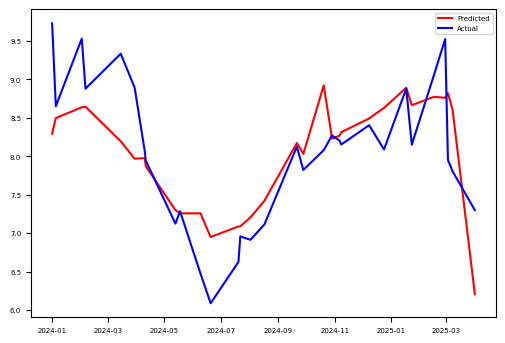

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(df_m["day"], df_m["max_P_kw_pred"], "r", label="Predicted")
plt.plot(df_m["day"], df_m["max_P_kw"], "b", label="Actual")
print("R^2:", model.score(X, y), (df_m["max_P_kw_pred"] - df_m["max_P_kw"]).abs().sum())
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(df_m["day"], df_m["max_P_kw_pred"])
plt.plot(df_m["day"], df_m["max_P_kw"])
print("R^2:", model.score(X, y), (df_m["max_P_kw_pred"] - df_m["max_P_kw"]).abs().sum())

R^2: 0.5741128988437653 13.720215834470729


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(df_m["day"], df_m["max_P_kw_pred"])
plt.plot(df_m["day"], df_m["max_P_kw"])
print("R^2:", model.score(X, y), (df_m["max_P_kw_pred"] - df_m["max_P_kw"]).abs().sum())

R^2: 0.5741128988437653 13.720215834470729


In [ ]:
# Calculating max(GHI)/max(P_kw)
site_id = 1299741610
year = 2024
df = iceberg_sql(f"""with data as (select site_id, t_stamp,  sum(cast(power*circuit_polarity as decimal(38, 6)))/1000 as P_kw, 
                 sum(cast(energy_reactive*circuit_polarity as decimal(38, 6)))/1000*12 as Q_kvar, avg(voltage) as v_avg, n_lat, n_long
                 from ts inner join meta_up23c as m on ts.circuit_id = m.circuit_id
                 where site_id = {site_id} and year = {year} and ts.is_pv=True and voltage >= 200 and voltage <= 300
                 group by t_stamp,  site_id, n_lat, n_long),

                 bom10min as (select distinct time, b.latitude, b.longitude, surface_global_irradiance as GHI, cloud_type
                 from bom_nci.solar as b
                 inner join meta_up23c as m on b.latitude = m.n_lat and b.longitude = m.n_long
                 where year={year} and site_id = {site_id}),

                  bom5min as ((select time as time_5min, latitude, longitude, GHI, cloud_type
                 from bom10min) union all
                 (select date_add('minute', 5, time) as time_5min, latitude, longitude,
                 GHI, cloud_type
                 FROM bom10min
                  ORDER BY time_5min)),
                  clear_sky as (select date_trunc('day', time + interval '10' hour) AS day
                  from bom10min
                  group by date_trunc('day', time + interval '10' hour)
                  having sum(cloud_type) = 0
                  )

                 select  site_id, date_trunc('day', t_stamp + interval '10' hour) AS day , max(GHI) as max_GHI, max(P_kw) as max_P_kw
                 from data as d left join bom5min as b on 
                 d.n_lat = b.latitude and d.n_long = b.longitude and d.t_stamp = b.time_5min
                 where date_trunc('day', t_stamp + interval '10' hour)  in (select day from clear_sky)
                 group by site_id, date_trunc('day', t_stamp + interval '10' hour)
                 order by day
               
""")
# having count(cloud_type=0) > 10
# having sum(cloud_type) = 0
# df['t_stamp'] = pd.to_datetime(df['t_stamp']).dt.tz_localize('utc').dt.tz_convert(pytz.FixedOffset(10*60))
# df['GHI'] = df['GHI'].fillna(-1)
# df['cloud_type'] = df['cloud_type'].fillna(-1)
df

,site_id,day,max_GHI,max_P_kw
0,1299741610,2024-01-21,1046.58,7.238517
1,1299741610,2024-03-25,859.06,6.995013
2,1299741610,2024-03-30,817.82,6.655613
3,1299741610,2024-04-01,803.28,6.640413
4,1299741610,2024-04-06,781.62,6.821347
5,1299741610,2024-04-12,757.31,6.646290
6,1299741610,2024-04-23,707.70,6.339120
7,1299741610,2024-04-25,700.19,6.373703
8,1299741610,2024-04-26,686.65,6.362863
9,1299741610,2024-05-14,616.62,5.862140


In [ ]:
start_time = f"{year}-{month:02d}-2 00:00:00+10:00"  # In sydney local time
end_time = f"{year}-{month:02d}-10 00:00:00+10:00"  # In sydney local time


num_ticks = 24 * 2 + 1
save_as = ""
x_label = "time"
y_labels = [
    "Active power (kW)",
    "Reactive power (kvar)",
    "GHI",
    "Cloud Type",
    "Apparent Power (kVA)",
    "Average Voltage (V)",
    "Power Factor",
]
plt_config = {
    "P_kw": [1, 0, "-", None, None],
    "Q_kvar": [1, 1, "-", None, None],
    "GHI": [0, 0, "-", None, None],
    "cloud_type": [0, 1, "-", None, None],
    "S_kva": [2, 0, "-", None, None],
    "v_avg": [2, 1, "-", None, None],
    "pf": [3, 0, "-", None, None],
}

color_nights = False
# color_by = 'group'
color_by = "attribute"
ax_digit = "1.1f"
a = my_plot4(
    start_time,
    end_time,
    df,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="site_id",
    time_attr="t_stamp",
    color_nights=color_nights,
    cmap="plasma",
    figsize=[16 / 2.54, 1.5],
    same_scale=1,
    fontsize=5,
    fontname="DejaVu Sans",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    num_ticks=num_ticks,
    num_yticks=10,
    dpi=300,
    x_format="%H:%M",
    legend_loc=[
        "center left",
        "upper right",
        "center left",
        "upper right",
        "center left",
    ],
    x_label=x_label,
    y_labels=y_labels,
    color_by=color_by,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=60,
    step=0,
    gridwidth=[0.2, 0.2],
    legend_join="-",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
    onlyntime=0,
)
a.do()

NameError: name 'df7777' is not defined

In [ ]:
hive_sql("""
         select distinct s.site_id, s.latitude, s.longitude
         from 
         sites as s 
""")

,site_id,latitude,longitude
0,1944472430,-34.470,150.85
1,1492891952,-23.400,150.50
2,1780063290,-12.465,131.00
3,302260061,-27.630,153.30
4,1955208720,-23.715,133.85
...,...,...,...
37618,572834115,-33.840,150.85
37619,662608029,-28.530,153.55
37620,620406052,-21.150,149.05
37621,1722930229,-37.800,145.00
